## Importing Dependencies

In [28]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading Constrained Realizations Into Dataframe

In [29]:
filename = "./constrainedMilkyWay.hdf5"
output = "Output1"

cols = [
    "satellitePositionX",
    "satellitePositionY",
    "satellitePositionZ",
    "basicMass",
    "nodeIndex",
    "parentIndex",
    "nodeLabelLMC",
    "nodeLabelIsLMCSubhalo",
    "nodeLabelWasLMCSubhalo",
    "basicTimeLastIsolated",
    "nodeIsIsolated"
]

with h5py.File(filename, "r") as f:
    node_path = f"Outputs/{output}/nodeData"
    out_path = f"Outputs/{output}"

    print("Number of nodeData columns:", len(f[node_path].keys()))

    print("\nColumns being loaded:")
    for col in cols:
        dset = f[f"{node_path}/{col}"]
        print(col, dset.shape, dset.dtype)

    data = {col: f[f"{node_path}/{col}"][:] for col in cols}

    tree_start = f[f"{out_path}/mergerTreeStartIndex"][:]
    tree_count = f[f"{out_path}/mergerTreeCount"][:]
    tree_index = f[f"{out_path}/mergerTreeIndex"][:]

constrained_df = pd.DataFrame(data)

tree_id = np.full(len(constrained_df), -1, dtype=np.int64)

for start, count, idx in zip(tree_start, tree_count, tree_index):
    start = int(start)
    count = int(count)
    idx = int(idx)

    tree_id[start:start + count] = idx

constrained_df["tree_id"] = tree_id

constrained_df["absolute_distance"] = np.linalg.norm(
    constrained_df[["satellitePositionX", "satellitePositionY", "satellitePositionZ"]].to_numpy(),
    axis=1
)


constrained_df = constrained_df[constrained_df["nodeIsIsolated"] != 1].reset_index(drop=True)

print(constrained_df["nodeIsIsolated"].value_counts())

# print(constrained_df["absolute_distance"].describe())
# print(constrained_df.describe())

Number of nodeData columns: 25

Columns being loaded:
satellitePositionX (1315643,) float64
satellitePositionY (1315643,) float64
satellitePositionZ (1315643,) float64
basicMass (1315643,) float64
nodeIndex (1315643,) int64
parentIndex (1315643,) int64
nodeLabelLMC (1315643,) int64
nodeLabelIsLMCSubhalo (1315643,) int64
nodeLabelWasLMCSubhalo (1315643,) int64
basicTimeLastIsolated (1315643,) float64
nodeIsIsolated (1315643,) int64
nodeIsIsolated
0    1305643
Name: count, dtype: int64


## Loading Unconstrained Realizations Into Dataframe

In [30]:
filename = "./unconstrainedMilkyWay.hdf5"
output = "Output1"

cols = [
    "satellitePositionX",
    "satellitePositionY",
    "satellitePositionZ",
    "basicMass",
    "nodeIndex",
    "parentIndex",
    "basicTimeLastIsolated",
    "nodeIsIsolated"
]

with h5py.File(filename, "r") as f:
    node_path = f"Outputs/{output}/nodeData"
    out_path = f"Outputs/{output}"

    print("Number of nodeData columns:", len(f[node_path].keys()))

    print("\nColumns being loaded:")
    for col in cols:
        dset = f[f"{node_path}/{col}"]
        print(col, dset.shape, dset.dtype)

    data = {col: f[f"{node_path}/{col}"][:] for col in cols}

    tree_start = f[f"{out_path}/mergerTreeStartIndex"][:]
    tree_count = f[f"{out_path}/mergerTreeCount"][:]
    tree_index = f[f"{out_path}/mergerTreeIndex"][:]

unconstrained_df = pd.DataFrame(data)

tree_id = np.full(len(unconstrained_df), -1, dtype=np.int64)

for start, count, idx in zip(tree_start, tree_count, tree_index):
    start = int(start)
    count = int(count)
    idx = int(idx)

    tree_id[start:start + count] = idx

unconstrained_df["tree_id"] = tree_id

unconstrained_df["absolute_distance"] = np.linalg.norm(
    unconstrained_df[["satellitePositionX", "satellitePositionY", "satellitePositionZ"]].to_numpy(),
    axis=1
)

unconstrained_df = unconstrained_df[unconstrained_df["nodeIsIsolated"] != 1].reset_index(drop=True)

print(unconstrained_df["nodeIsIsolated"].value_counts())

# print(unconstrained_df["absolute_distance"].describe())
# print(unconstrained_df.describe())


Number of nodeData columns: 22

Columns being loaded:
satellitePositionX (1316289,) float64
satellitePositionY (1316289,) float64
satellitePositionZ (1316289,) float64
basicMass (1316289,) float64
nodeIndex (1316289,) int64
parentIndex (1316289,) int64
basicTimeLastIsolated (1316289,) float64
nodeIsIsolated (1316289,) int64
nodeIsIsolated
0    1306289
Name: count, dtype: int64


## Constants

In [31]:
total_tree_count = len(tree_start)
print(f"Total number of merger trees: {total_tree_count}")

Total number of merger trees: 10000


## Finding SMC Candidates In Constrained Data

In [32]:
min_smc_mass = 5.0e9
max_smc_mass = 8.0e9

min_smc_distance = 0.02
max_smc_distance = 0.04

smc_candidate_mask = (
    (constrained_df["nodeLabelWasLMCSubhalo"] == 1) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

selected = constrained_df[smc_candidate_mask]
selected_ids = selected["tree_id"].tolist()
unique_selected_ids = set(selected_ids)
tree_id_with_multiple_candidates = selected["tree_id"].value_counts()
trees_with_multiple_candidates = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates > 1].index.tolist()
trees_with_single_candidate = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates == 1].index.tolist()

print(selected.columns)
print("Selected tree IDs:", selected_ids)
print("Trees with multiple candidates:", trees_with_multiple_candidates)
print("Trees with single candidate:", trees_with_single_candidate)
print("Number selected:", len(selected))
print("Number of unique tree IDs:", len(unique_selected_ids))
print("Number of trees with multiple candidates:", len(trees_with_multiple_candidates))
print("Number of trees with single candidate:", len(trees_with_single_candidate))


Index(['satellitePositionX', 'satellitePositionY', 'satellitePositionZ',
       'basicMass', 'nodeIndex', 'parentIndex', 'nodeLabelLMC',
       'nodeLabelIsLMCSubhalo', 'nodeLabelWasLMCSubhalo',
       'basicTimeLastIsolated', 'nodeIsIsolated', 'tree_id',
       'absolute_distance'],
      dtype='str')
Selected tree IDs: [9910, 9838, 9990, 9787, 9971, 9950, 9761, 9859, 9656, 9785, 9736, 9608, 9480, 9550, 9670, 9858, 9681, 9585, 9806, 9542, 9887, 9781, 9192, 9526, 9475, 9810, 9478, 9446, 9048, 9137, 9379, 9400, 8985, 9685, 9334, 9994, 9201, 8840, 9324, 9428, 9158, 8780, 9380, 8505, 8969, 9357, 9332, 9551, 9964, 8825, 8995, 9462, 9326, 8729, 9278, 8247, 8913, 8681, 9682, 9230, 9635, 8151, 8007, 8710, 9349, 8345, 8973, 7640, 7767, 7678, 8755, 7497, 8673, 8799, 9530, 8532, 9170, 7431, 8831, 7017, 9930, 7224, 7239, 7054, 7481, 6977, 8071, 8134, 8445, 8086, 9697, 8246, 6440, 6571, 7049, 8222, 9775, 8039, 6449, 7816, 6475, 8035, 6615, 7783, 6504, 8061, 9203, 9298, 8544, 7635, 5768, 5921, 6425

## SMC Candidates of trees with Multiple Candidates

In [33]:
special_smc_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_multiple_candidates)) &
    (constrained_df["nodeLabelWasLMCSubhalo"] == 1) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

special_candidates = constrained_df[special_smc_candidate_mask]
print("Number of special candidates:", len(special_candidates))

Number of special candidates: 24


## SMC Candidates from trees with only one SMC

In [34]:
regular_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_single_candidate)) &
    (constrained_df["nodeLabelWasLMCSubhalo"] == 1) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

regular_candidates = constrained_df[regular_candidate_mask]
print("Number of unique candidates:", len(regular_candidates))


Number of unique candidates: 594


## Histograms of Infall times of Regular Candidates vs Special Candidates

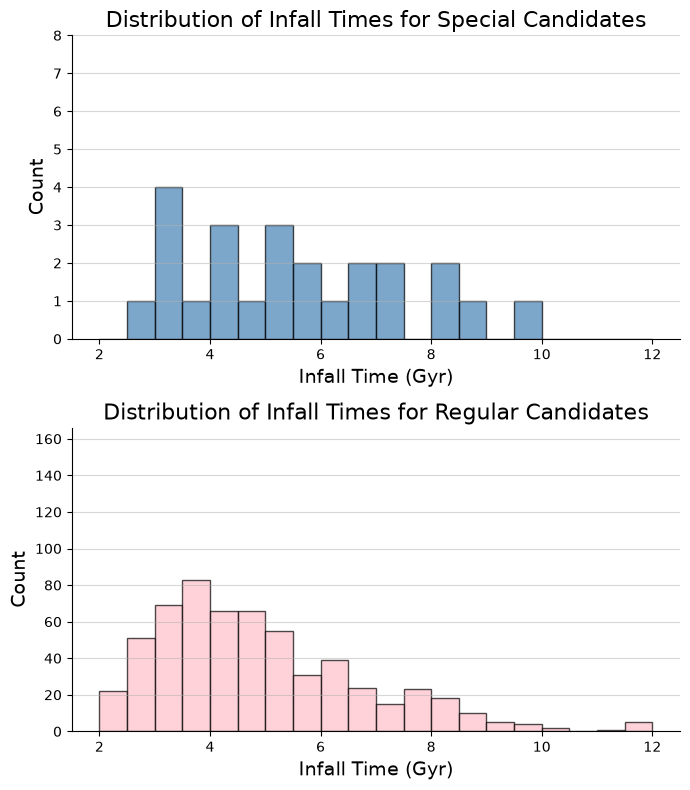

In [35]:
fig, ax = plt.subplots(2, 1, figsize = (7, 8))
bins = np.arange(2, 12.5, 0.5)

ax[0].hist(special_candidates["basicTimeLastIsolated"], bins=bins, color = "steelblue", edgecolor='black', alpha=0.7)
ax[0].set_title("Distribution of Infall Times for Special Candidates", fontsize=16)
ax[0].set_xlabel("Infall Time (Gyr)", fontsize=14)
ax[0].set_ylabel("Count", fontsize=14)
ax[0].set_ymargin(1)
ax[0].grid(axis='y', alpha=0.5)

ax[1].hist(regular_candidates["basicTimeLastIsolated"], bins=bins, color = "pink", edgecolor='black', alpha=0.7)
ax[1].set_title("Distribution of Infall Times for Regular Candidates", fontsize=16)
ax[1].set_xlabel("Infall Time (Gyr)", fontsize=14)
ax[1].set_ylabel("Count", fontsize=14)
ax[1].set_ymargin(1)
ax[1].grid(axis='y', alpha=0.5)

for axis in ax:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



# Mass Function

## Cummulative Mass Function

In [36]:
def cum_mass(m_sub):
    m_sub = np.array(m_sub)
    sorted_masses = np.sort(m_sub)

    idx = np.searchsorted(sorted_masses, sorted_masses, side="right")
    N = (len(sorted_masses) - idx)/ total_tree_count
    return sorted_masses, N


## Generate X and Y From Constrained

In [37]:
constrained_m_sub = constrained_df["basicMass"].to_list()
constrained_x, constrained_y = cum_mass(constrained_m_sub)
print(constrained_x)
print(constrained_y)

[9.98553634e+07 9.98974249e+07 9.99747479e+07 ... 4.93540453e+11
 4.94709047e+11 4.97967129e+11]
[1.305642e+02 1.305641e+02 1.305640e+02 ... 2.000000e-04 1.000000e-04
 0.000000e+00]


## Generate X and Y From Unconstrained

In [38]:
unconstrained_m_sub = unconstrained_df["basicMass"].to_list()
unconstrained_x, unconstrained_y = cum_mass(unconstrained_m_sub)
print(unconstrained_x)
print(unconstrained_y)

[9.99224270e+07 9.99261655e+07 9.99329704e+07 ... 4.85910526e+11
 4.94126174e+11 4.97479266e+11]
[1.306288e+02 1.306287e+02 1.306286e+02 ... 2.000000e-04 1.000000e-04
 0.000000e+00]


## Make Mass Function Plot

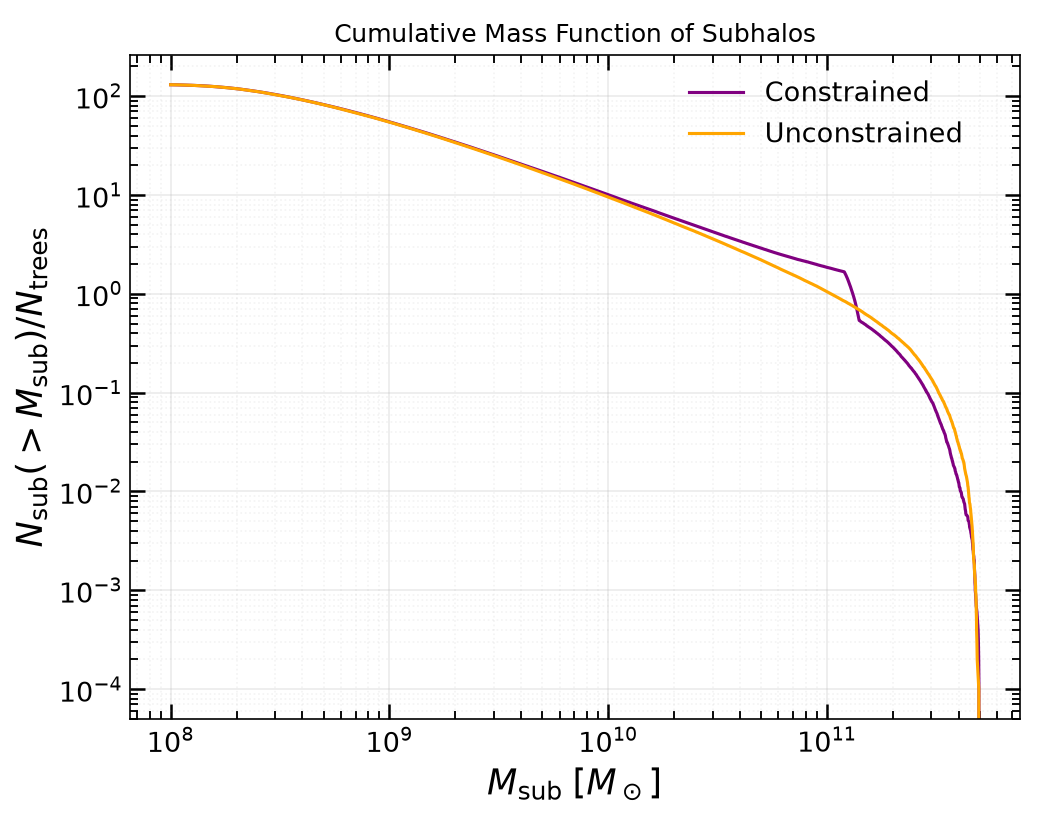

In [39]:
fig, ax = plt.subplots(figsize= (7, 5.5), dpi= 150)

ax.plot(constrained_x, constrained_y, color= "purple")
ax.plot(unconstrained_x, unconstrained_y, color= "orange")
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$M_{\rm sub}\;[M_\odot]$", fontsize=17)
ax.set_ylabel(r"$N_{\rm sub}(>M_{\rm sub})/ N_{\rm trees}$", fontsize=17)

ax.tick_params(axis="both", which="major", labelsize=13, direction="in", length=7, width=1.2)
ax.tick_params(axis="both", which="minor", direction="in", length=4, width=0.9)
ax.tick_params(top=True, right=True, which="both")

ax.grid(True, which="major", linestyle="-", alpha=0.25)
ax.grid(True, which="minor", linestyle=":", alpha=0.15)
ax.title.set_text("Cumulative Mass Function of Subhalos")

fig.legend(["Constrained", "Unconstrained"], fontsize=13, loc="upper right", frameon=False, borderpad=2.5)
fig.tight_layout()
plt.show()


## SMCs Still Associated with their Subhalos

In [40]:
bound_smcs = selected[
    (selected["nodeLabelIsLMCSubhalo"] == 1)
]
regular_bound_smcs = regular_candidates[
    (regular_candidates["nodeLabelIsLMCSubhalo"] == 1)
]
special_bound_smcs = special_candidates[
    (special_candidates["nodeLabelIsLMCSubhalo"] == 1)
]
print (bound_smcs["tree_id"].to_list())
print (regular_bound_smcs["tree_id"].to_list())
print (special_bound_smcs["tree_id"].to_list())
print("Number of regular bound SMC candidates:", len(regular_bound_smcs))
print("Number of special bound SMC candidates:", len(special_bound_smcs))
print("Number of bound SMC candidates:", len(bound_smcs))

[9910, 9838, 9990, 9787, 9950, 9761, 9859, 9656, 9785, 9736, 9608, 9480, 9550, 9670, 9858, 9681, 9585, 9806, 9542, 9887, 9781, 9192, 9526, 9475, 9810, 9478, 9446, 9048, 9137, 9379, 9400, 8985, 9685, 9334, 9994, 9201, 9324, 9428, 9158, 8780, 9380, 8505, 8969, 9357, 9551, 9964, 8825, 8995, 9462, 9326, 8729, 9278, 8247, 8913, 8681, 9682, 9230, 9635, 8151, 8007, 8710, 9349, 8345, 8973, 7640, 7767, 7678, 8755, 7497, 8673, 8799, 9530, 8532, 9170, 7431, 8831, 7017, 9930, 7224, 7239, 7054, 7481, 6977, 8071, 8134, 8445, 8086, 9697, 8246, 6440, 6571, 7049, 8222, 9775, 8039, 6449, 7816, 6475, 8035, 6615, 7783, 8061, 9203, 8544, 7635, 5768, 5921, 6425, 7655, 7699, 8049, 5806, 5825, 7773, 7622, 7222, 7646, 9649, 5895, 7629, 7459, 5192, 8762, 5000, 7351, 5201, 4809, 5640, 5009, 4961, 6406, 4769, 4520, 6935, 5225, 7027, 4328, 4233, 5033, 6708, 4529, 6627, 4481, 4937, 4385, 5830, 5208, 6911, 4551, 6734, 6813, 4145, 4145, 4171, 3752, 8809, 8723, 4361, 6621, 3608, 6147, 9556, 3646, 6871, 3225, 7062, 359